In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

## 1. Overview

In [3]:
df = pd.read_csv("student_lifestyle_dataset.csv")

In [24]:
df.head(10)

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High
5,6,6.0,2.1,8.0,0.3,7.6,2.85,Moderate
6,7,8.0,0.7,5.3,5.7,4.3,3.08,High
7,8,8.4,1.8,5.6,3.0,5.2,3.20,High
8,9,5.2,3.6,6.3,4.0,4.9,2.82,Low
9,10,7.7,0.7,9.8,4.5,1.3,2.76,Moderate


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   float64
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   float64
 4   Social_Hours_Per_Day             2000 non-null   float64
 5   Physical_Activity_Hours_Per_Day  2000 non-null   float64
 6   GPA                              2000 non-null   float64
 7   Stress_Level                     2000 non-null   str    
dtypes: float64(6), int64(1), str(1)
memory usage: 125.1 KB


In [5]:
df.describe()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,1000.500000,7.475800,1.990100,7.501250,2.704550,4.32830,3.115960
std,577.494589,1.423888,1.155855,1.460949,1.688514,2.51411,0.298674
min,1.000000,5.000000,0.000000,5.000000,0.000000,0.00000,2.240000
25%,500.750000,6.300000,1.000000,6.200000,1.200000,2.40000,2.900000
50%,1000.500000,7.400000,2.000000,7.500000,2.600000,4.10000,3.110000
75%,1500.250000,8.700000,3.000000,8.800000,4.100000,6.10000,3.330000
max,2000.000000,10.000000,4.000000,10.000000,6.000000,13.00000,4.000000


GPA ranges from 2,24 to 4.00 with average 3.116 and relative small standard 0.3.
Student studies about average 7.4758 hour a day, from 5 to 10 hour with standard 1.424  
Student spends average 7.5 hour a day for sleeping (thew highest average of all activities)
Besides, they spends average 2.7 and approximate 2 hour a day for social activity and extracurrilar respectively.

In [23]:
df.duplicated().sum()

np.int64(0)

## 2. Visualize data

Reject identify column Student_ID 

In [19]:
eda_df = df.drop(columns=["Student_ID"])

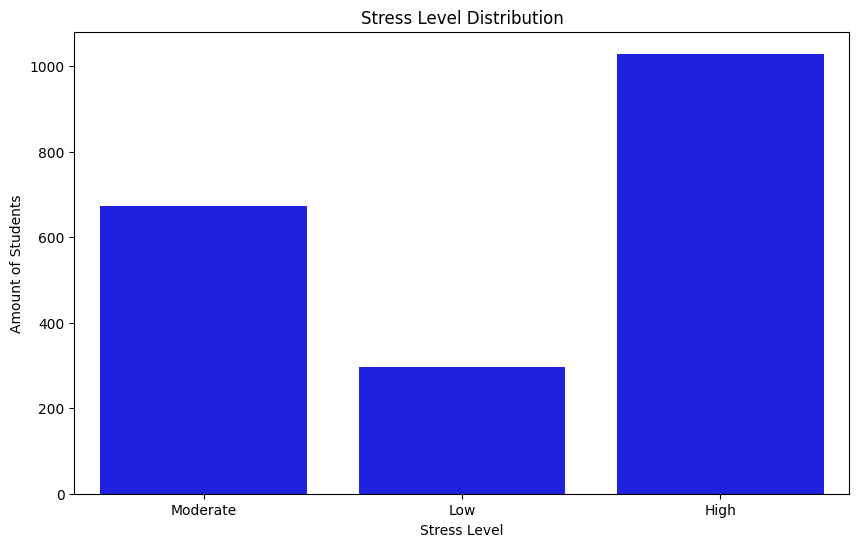

In [20]:
## Visualize Stress Level Distribution
plt.figure(figsize=(10,6))

sns.countplot(data=eda_df, x="Stress_Level", color = 'blue')

plt.title("Stress Level Distribution")
plt.xlabel("Stress Level")
plt.ylabel("Amount of Students")
plt.show()

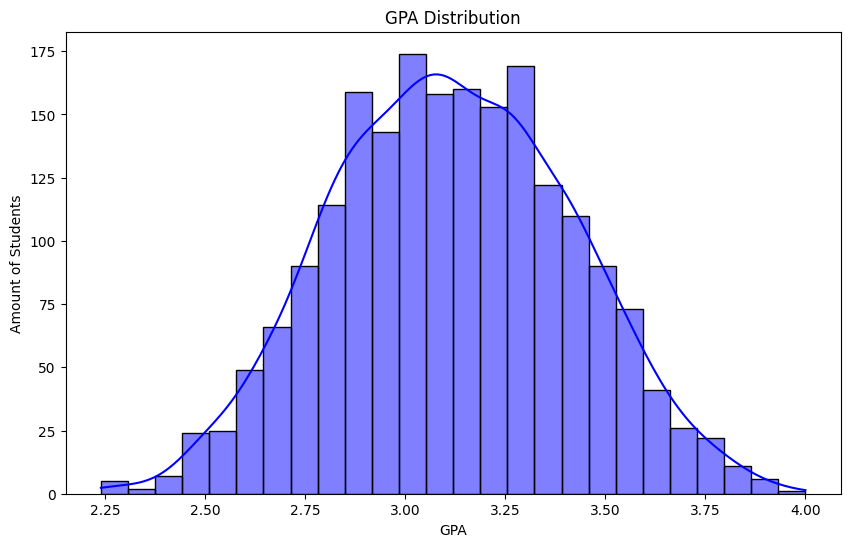

In [21]:
## Visualize GPA Distribution
plt.figure(figsize=(10,6))

sns.histplot(data=eda_df, x="GPA", kde=True, color='blue')

plt.title("GPA Distribution")
plt.xlabel("GPA")
plt.ylabel("Amount of Students")
plt.show()

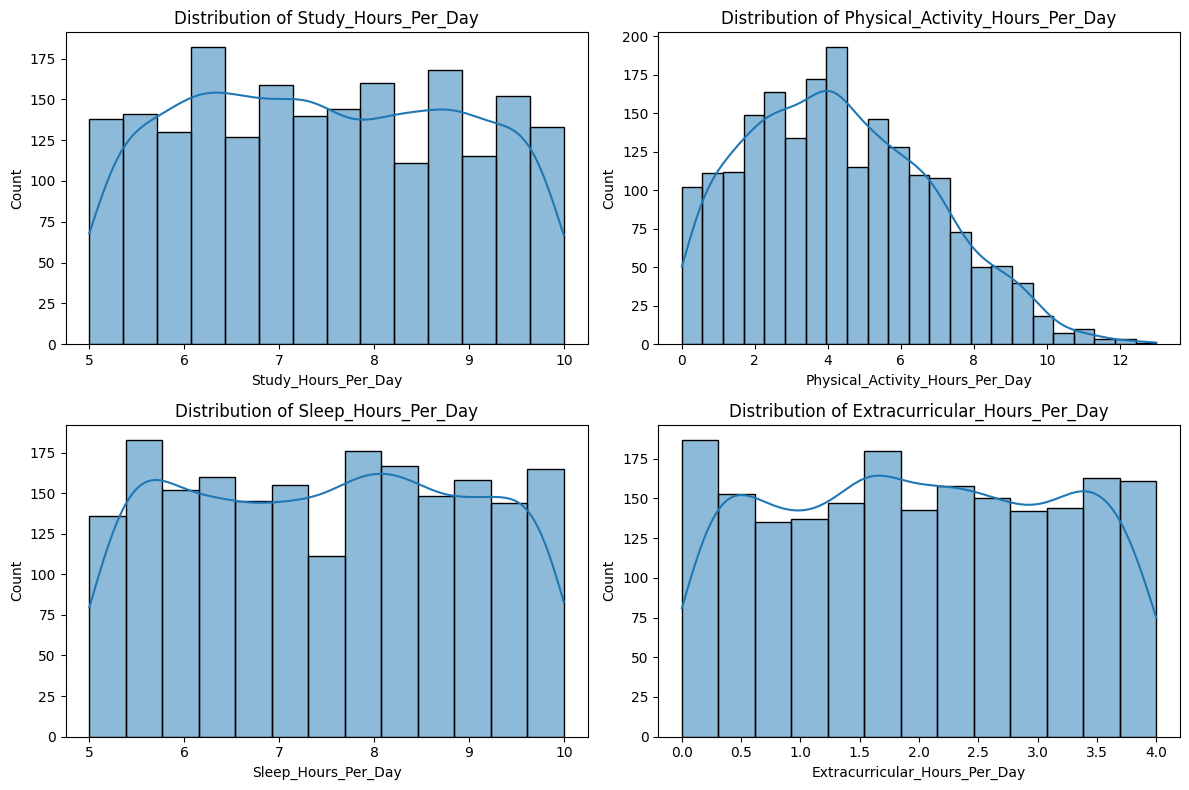

In [ ]:
## Visualize Time for Activities on day Distributions
cols = ["Study_Hours_Per_Day", "Physical_Activity_Hours_Per_Day", "Sleep_Hours_Per_Day", "Extracurricular_Hours_Per_Day"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(
        data=eda_df,
        x=col,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(
        f"Distribution of {col}"
    )

plt.tight_layout()
plt.show()

##  3. Correlation Analysis

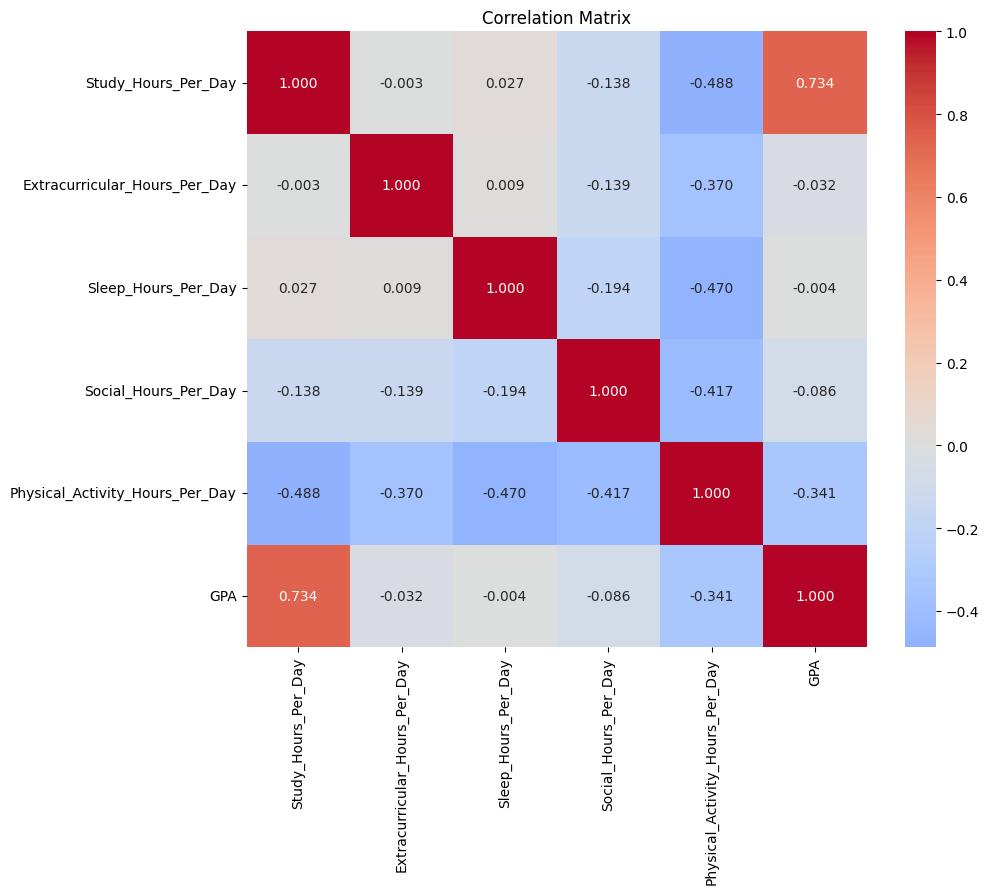

In [22]:
corr_matrix = eda_df.corr(
    numeric_only=True
)


plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

Study Hours Per Day shows the strongest positive correlation with GPA.
Meanwhile, Stress Level is negatively correlated with GPA.
In other hand, time for physical activities is considerable correlated with others

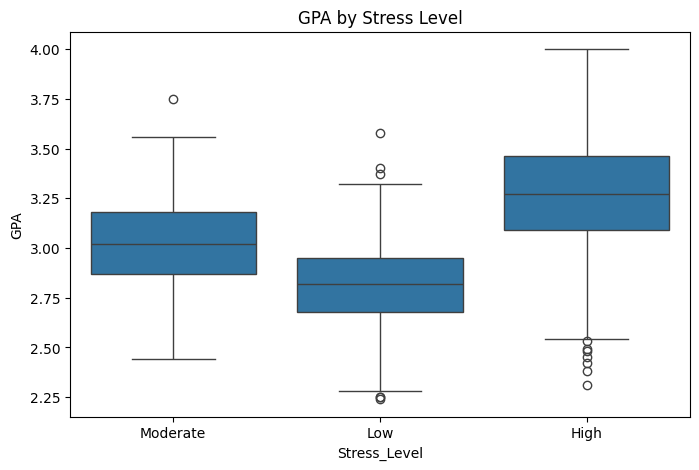

In [32]:
## Visualize GPA by Stress Level
plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda_df,
    x="Stress_Level",
    y="GPA"
)

plt.title("GPA by Stress Level")

plt.show()

Obviously, student in higher level of stress tends to have lower GPA and vice versa